# Multilayer Network Analysis
This notebook guides you through building and analyzing a multilayer network.

In [6]:
# 1. Install packages (run once if needed)
# python -m pip install pymnet networkx pandas matplotlib

In [7]:
import pymnet
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [8]:
# 2. Create multilayer network
net = pymnet.MultiplexNetwork(couplings='categorical', fullyInterconnected=False)

net['Olefins','Ethylene oxide','Materials'] = 200
net['Ethylene oxide','PTA','Materials'] = 150
net['PTA','PET','Materials'] = 300
net['PTA','Olefins','Energy'] = 40

print(list(net.iter_nodes()))
print(list(net.iter_layers()))

['PTA', 'Ethylene oxide', 'PET', 'Olefins']
['Materials', 'Energy']


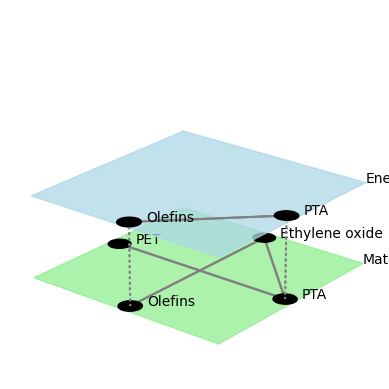

In [9]:
# 3. Visualize
pymnet.draw(net, layout='circular', layerColorDict={'Materials':'lightgreen','Energy':'lightblue'})
plt.show()

In [11]:
#4.	Calcule single layer network properties
# Calculate Degree Centrality (non-normalized)
layers = list(net.iter_layers())
edges = list(net.edges)

for layer in layers:
    print("Layer:", layer)

    G = nx.DiGraph()

    for edge in edges:
        n1 = edge[0]
        n2 = edge[1]
        l1 = edge[2]
        l2 = edge[3]

        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2)

    for node, degree in G.degree():
        print(node, "C_D =", degree)

    print()

Layer: Materials
PTA C_D = 2
Ethylene oxide C_D = 2
PET C_D = 1
Olefins C_D = 1

Layer: Energy
PTA C_D = 1
Olefins C_D = 1



In [12]:
# Calculate Betweenness centrality (intermediary companies)
for layer in layers:
    print("Layer:", layer)
    
    G = nx.DiGraph()
    
    for edge in edges:
        n1 = edge[0]
        n2 = edge[1]
        l1 = edge[2]
        l2 = edge[3]
        
        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2)
    
    if len(G.nodes) > 0:
        bet = nx.betweenness_centrality(G, normalized=False)
        
        for node, value in bet.items():
            print(node, "C_B =", round(value, 3))
    
    print()

Layer: Materials
PTA C_B = 0.0
Ethylene oxide C_B = 1.0
PET C_B = 0.0
Olefins C_B = 0.0

Layer: Energy
PTA C_B = 0.0
Olefins C_B = 0.0



In [13]:
# Calculate graph density
for layer in layers:
    print("Layer:", layer)

    G = nx.Graph()

    for edge in edges:
        n1 = edge[0]
        n2 = edge[1]
        l1 = edge[2]
        l2 = edge[3]

        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2)

    N = len(G.nodes)
    M = len(G.edges)

    if N > 1:
        density = M / (N * (N - 1))
        print("Graph density =", round(density, 3))
        print()

Layer: Materials
Graph density = 0.25

Layer: Energy
Graph density = 0.5



In [14]:
#Calculate Strength (links)
for layer in layers:
     print("Layer:", layer)
     G = nx.DiGraph()
     for edge in edges:
         n1 = edge[0]
         n2 = edge[1]
         l1 = edge[2]
         l2 = edge[3]
         w  = edge[4]
         if l1 == layer and l2 == layer:
             G.add_edge(n1, n2, weight=w)
     for node in G.nodes():
         strength = sum(data["weight"] for _,_,data in G.edges(node, data=True))
         print(node, "S =", strength)
     print()


Layer: Materials
PTA S = 450
Ethylene oxide S = 200
PET S = 0
Olefins S = 0

Layer: Energy
PTA S = 40
Olefins S = 0



In [15]:
#5.	Create Property Matrix (Nodes x Properties)
import pandas as pd
rows = []
for layer in layers:
     G = nx.DiGraph()
     for edge in edges:
         n1 = edge[0]
         n2 = edge[1]
         l1 = edge[2]
         l2 = edge[3]
         w  = edge[4]
         if l1 == layer and l2 == layer:
             G.add_edge(n1, n2, weight=w)
     degree = dict(G.degree())
     strength = dict(G.degree(weight="weight"))
     betweenness = nx.betweenness_centrality(G, normalized=False)
     for node in G.nodes():
        rows.append({ "Node": node, "Layer": layer, "Degree": degree[node], "Strength": strength[node], "Betweenness": betweenness[node] })
property_matrix = pd.DataFrame(rows)
print(property_matrix)


             Node      Layer  Degree  Strength  Betweenness
0             PTA  Materials       2       450          0.0
1  Ethylene oxide  Materials       2       350          1.0
2             PET  Materials       1       300          0.0
3         Olefins  Materials       1       200          0.0
4             PTA     Energy       1        40          0.0
5         Olefins     Energy       1        40          0.0


In [16]:
#6.	Calculate multiplex properties
# Calculate total strength across layers
node_strength = {}

for layer in layers:
    G = nx.DiGraph()

    for edge in edges:
        n1 = edge[0]
        n2 = edge[1]
        l1 = edge[2]
        l2 = edge[3]
        w  = edge[4]

        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2, weight=w)

    for node in G.nodes():
        s = sum(data["weight"] for _, _, data in G.edges(node, data=True))

        if node not in node_strength:
            node_strength[node] = 0

        node_strength[node] += s

print("Multiplex strength:")
for node, value in node_strength.items():
    print(node, value)

Multiplex strength:
PTA 490
Ethylene oxide 200
PET 0
Olefins 0


In [17]:
# Calculate degree per layer
results = {}

for layer in layers:
    G = nx.Graph()

    for edge in edges:
        n1, n2, l1, l2, w = edge

        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2, weight=w)

    # compute degree (unweighted here)
    for node in G.nodes():
        degree = G.degree(node)

        if node not in results:
            results[node] = {"Degree_M": 0, "Degree_E": 0}

        if layer == "Materials":
            results[node]["Degree_M"] = degree
        elif layer == "Energy":
            results[node]["Degree_E"] = degree


In [19]:
#7.	Create a Nodes x Layers degree matrix
node_layer_degree = {}

for layer in layers:
    G = nx.DiGraph()

    for edge in edges:
        n1 = edge[0]
        n2 = edge[1]
        l1 = edge[2]
        l2 = edge[3]
        w  = edge[4]

        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2, weight=w)

    for node in G.nodes():
        degree = G.degree(node)

        if node not in node_layer_degree:
            node_layer_degree[node] = {}

        node_layer_degree[node][layer] = degree

# Print matrix
print("Node\tMaterials\tEnergy")

for node, values in node_layer_degree.items():
    materials = values.get("Materials", 0)
    energy = values.get("Energy", 0)

    print(node, "\t", materials, "\t", energy)


Node	Materials	Energy
PTA 	 2 	 1
Ethylene oxide 	 2 	 0
PET 	 1 	 0
Olefins 	 1 	 1


In [20]:
# Calculate Participation Coefficient
participation = {}
print("\nParticipation Coefficient")
for node, data in results.items():
    k_m = data["Degree_M"]
    k_e = data["Degree_E"]
    k_total = k_m + k_e

    if k_total == 0:
        P = 0
    else:
        P = 1 - ((k_m / k_total)**2 + (k_e / k_total)**2)
    participation[node] = P
    print(node, "P =", round(P, 3))
print("\nDegree per layer:")
for node, data in results.items():
    print(node, data)



Participation Coefficient
PTA P = 0.444
Ethylene oxide P = 0.0
PET P = 0.0
Olefins P = 0.5

Degree per layer:
PTA {'Degree_M': 2, 'Degree_E': 1}
Ethylene oxide {'Degree_M': 2, 'Degree_E': 0}
PET {'Degree_M': 1, 'Degree_E': 0}
Olefins {'Degree_M': 1, 'Degree_E': 1}


In [21]:
# Calculate interlayer connectivity
print("\nInterlayer Connectivity")
L = 2  # number of layers

for node, data in results.items():
    layers_active = 0

    if data["Degree_M"] > 0:
        layers_active += 1

    if data["Degree_E"] > 0:
        layers_active += 1

    IC = layers_active / L
    print(node, "IC =", round(IC, 2))


Interlayer Connectivity
PTA IC = 1.0
Ethylene oxide IC = 0.5
PET IC = 0.5
Olefins IC = 1.0


In [23]:
#8.	Build Multiplex property matrix 
import networkx as nx

layers = list(net.iter_layers())
edges = list(net.edges)

results = {}

for layer in layers:

    G = nx.DiGraph()

    for edge in edges:
        n1, n2, l1, l2, w = edge

        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2, weight=w)

    # Compute metrics
    degree = dict(G.degree())
    strength = dict(G.degree(weight="weight"))
    bet = nx.betweenness_centrality(G, normalized=False)

    for node in G.nodes():

        if node not in results:
            results[node] = {
                "Degree_M": 0, "Degree_E": 0,
                "Strength_M": 0, "Strength_E": 0,
                "Betweenness_M": 0, "Betweenness_E": 0
            }

        if layer == "Materials":
            results[node]["Degree_M"] = degree[node]
            results[node]["Strength_M"] = strength[node]
            results[node]["Betweenness_M"] = bet[node]

        if layer == "Energy":
            results[node]["Degree_E"] = degree[node]
            results[node]["Strength_E"] = strength[node]
            results[node]["Betweenness_E"] = bet[node]


# Print results
print("Node\tDegree_M\tDegree_E\tStrength_M\tStrength_E\tBetweenness_M\tBetweenness_E")

for node, data in results.items():
    print(node, "\t",
          data["Degree_M"], "\t",
          data["Degree_E"], "\t",
          data["Strength_M"], "\t",
          data["Strength_E"], "\t",
          round(data["Betweenness_M"], 3), "\t",
          round(data["Betweenness_E"], 3))

Node	Degree_M	Degree_E	Strength_M	Strength_E	Betweenness_M	Betweenness_E
PTA 	 2 	 1 	 450 	 40 	 0.0 	 0.0
Ethylene oxide 	 2 	 0 	 350 	 0 	 1.0 	 0
PET 	 1 	 0 	 300 	 0 	 0.0 	 0
Olefins 	 1 	 1 	 200 	 40 	 0.0 	 0.0


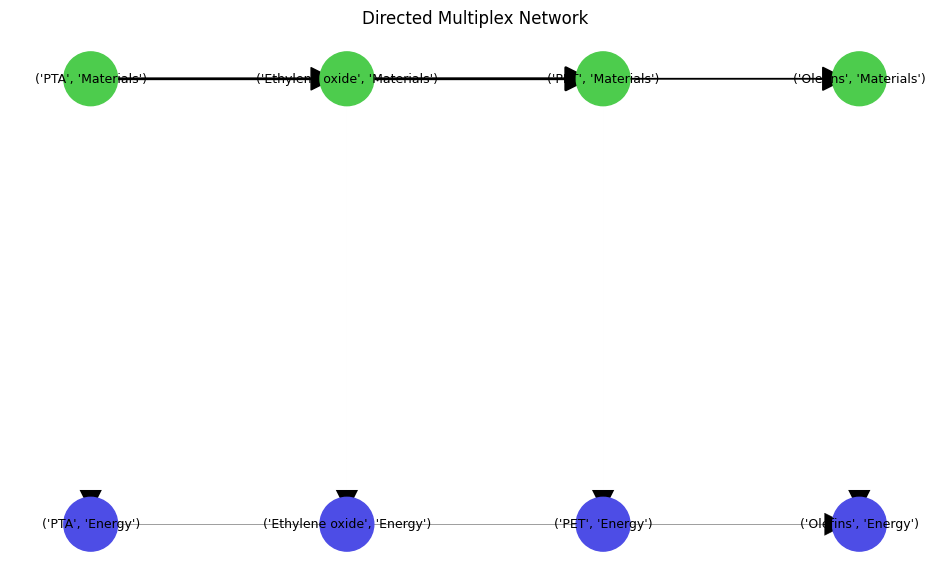

In [34]:
#9.	Create a multilayer network visualization with networkx
plt.figure(figsize=(12, 7))
pos = nx.spring_layout(G, k=0.8, iterations=100, seed=42)
# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=1500,
    node_color=node_colors
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=9
    font_color="white"
)

# Draw edges with arrows
nx.draw_networkx_edges(
    G, pos,
    width=weights,
    edge_color="black",
    arrows=True,
    arrowstyle='-|>',     
    arrowsize=40        
)

plt.title("Directed Multiplex Network")
plt.axis("off")
plt.show()


In [35]:
# 10. Calculate multiplex composite importance score
importance = {}
# Step 1: Calculate raw metrics
for node, data in results.items():
    degree_total = data["Degree_M"] + data["Degree_E"]
    strength_total = data["Strength_M"] + data["Strength_E"]
    bet_total = data["Betweenness_M"] + data["Betweenness_E"]

    k_m = data["Degree_M"]
    k_e = data["Degree_E"]
    k_total = k_m + k_e

    # Participation coefficient
    if k_total == 0:
        P = 0
    else:
        P = 1 - ((k_m / k_total) ** 2 + (k_e / k_total) ** 2)

    importance[node] = {
        "degree": degree_total,
        "strength": strength_total,
        "betweenness": bet_total,
        "participation": P
    }

# Step 2: Normalize values
metrics = ["degree", "strength", "betweenness", "participation"]

for metric in metrics:
    max_val = max((importance[n][metric] for n in importance), default=0)

    if max_val > 0:
        for node in importance:
            importance[node][metric] /= max_val

# Step 3: Calculate composite score
for node in importance:
    score = (
        importance[node]["degree"] +
        importance[node]["strength"] +
        importance[node]["betweenness"] +
        importance[node]["participation"]
    ) / 4

    importance[node]["score"] = score

# Step 4: Rank and print results
print("\nMultiplex Node Importance")

ranking = sorted(
    importance.items(),
    key=lambda x: x[1]["score"],
    reverse=True
)

for node, data in ranking:
    print(f"{node}: score = {data['score']:.3f}")


Multiplex Node Importance
PTA: score = 0.722
Ethylene oxide: score = 0.595
Olefins: score = 0.539
PET: score = 0.236
